## Access Station Lucinda Jetty Daily Wetlabs-Bb9 (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_daily_wetlabs-bb9 data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_daily_wetlabs-bb9.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_daily_wetlabs_bb9"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 500ms
Checked 155 packages in 2ms


✅ Local version 0.3.15 is up to date (remote: 0.3.15)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4355: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn()
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 1.4 s, sys: 86.2 ms, total: 1.48 s
Wall time: 3.71 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	TIME = 105856 ;
	WAVELENGTH = 9 ;

variables:
	float64 HEIGHT_water_sensor() ;
		HEIGHT_water_sensor:axis = Z ;
		HEIGHT_water_sensor:long_name = nominal height above sea surface of water sensor ;
		HEIGHT_water_sensor:positive = up ;
		HEIGHT_water_sensor:reference_datum = sea surface ;
		HEIGHT_water_sensor:standard_name = height ;
		HEIGHT_water_sensor:units = metres ;
		HEIGHT_water_sensor:valid_max = 0.0 ;
		HEIGHT_water_sensor:valid_min = -50.0 ;
	float64 LATITUDE() ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE() ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		LONGITUDE:units = degrees_ea

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2014-01-09 05:25:00'), Timestamp('2022-03-10 00:10:00'))

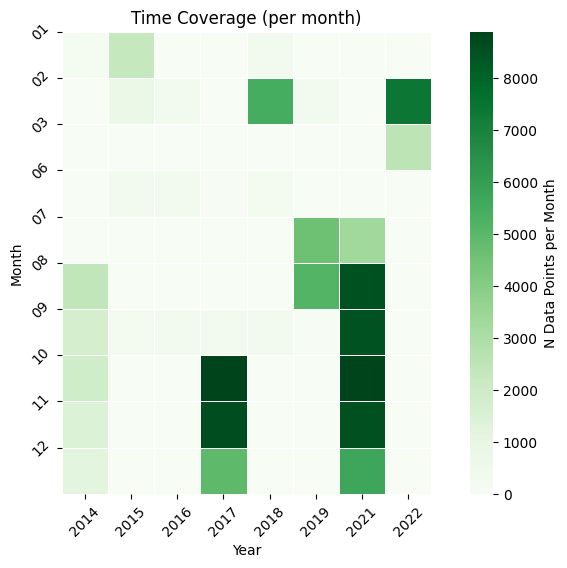

In [7]:
aodn_dataset.plot_time_coverage()